In [1]:
import jax
import jax.numpy as jnp
from jax import lax, vmap


def jaxviews(X, offsets, grid_shape):
    """
    Extract local patches using precomputed slice offsets.
    Returns shape: (*grid_shape, n_neighbors, d)
    """
    def extract(off):
        return lax.dynamic_slice(X, off, (*grid_shape, X.shape[-1]))

    patches = vmap(extract)(offsets)
    return jnp.moveaxis(patches, 0, -2)


def ground_state(points, IJ, wr, energy_fun, max_iter=100, lr=1e-2):
    """
    Gradient descent on a grid with frozen borders and local interaction energy.
    """
    ndim = len(IJ)
    grid_shape = jnp.array(IJ)

    # --- Neighbor offsets (relative → absolute slice indices) ---
    r = jnp.arange(-wr, wr + 1)
    rel = jnp.stack(jnp.meshgrid(*[r] * ndim, indexing="ij"), -1).reshape(-1, ndim)
    offsets = jnp.pad(rel + wr, ((0, 0), (0, 1)))

    # --- Frozen border mask ---
    border = jnp.maximum(1, (0.05 * jnp.min(grid_shape)).astype(int))
    assert wr < border

    p = jnp.reshape(jnp.array(points), (*IJ, -1))

    idx = jnp.meshgrid(*[jnp.arange(s) for s in IJ], indexing="ij")

    def energy(x):
        x_pad = jnp.pad(x, [(wr, wr)] * ndim + [(0, 0)], mode="wrap")
        neigh = jaxviews(x_pad, offsets, IJ)

        deltax = x[..., None, :] - neigh
        norm2 = (deltax**2).sum(axis=-1)
        return energy_fun(norm2)

    grad_fn = jax.grad(energy)

    def step(_, x):
        return x - lr * grad_fn(x) 

    p = lax.fori_loop(0, max_iter, step, p)
    return p.reshape(-1, p.shape[-1])

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from squarenet import SquareNet
from squarenet.utils import Potential

In [3]:
IJ = (500, 500)
I, J = IJ
N = I*J
D = 2

pts = np.random.rand(N, D)

sqnet = SquareNet(IJ_ = IJ)
sqnet.fit(pts)

succesfully sorted at iteration 12


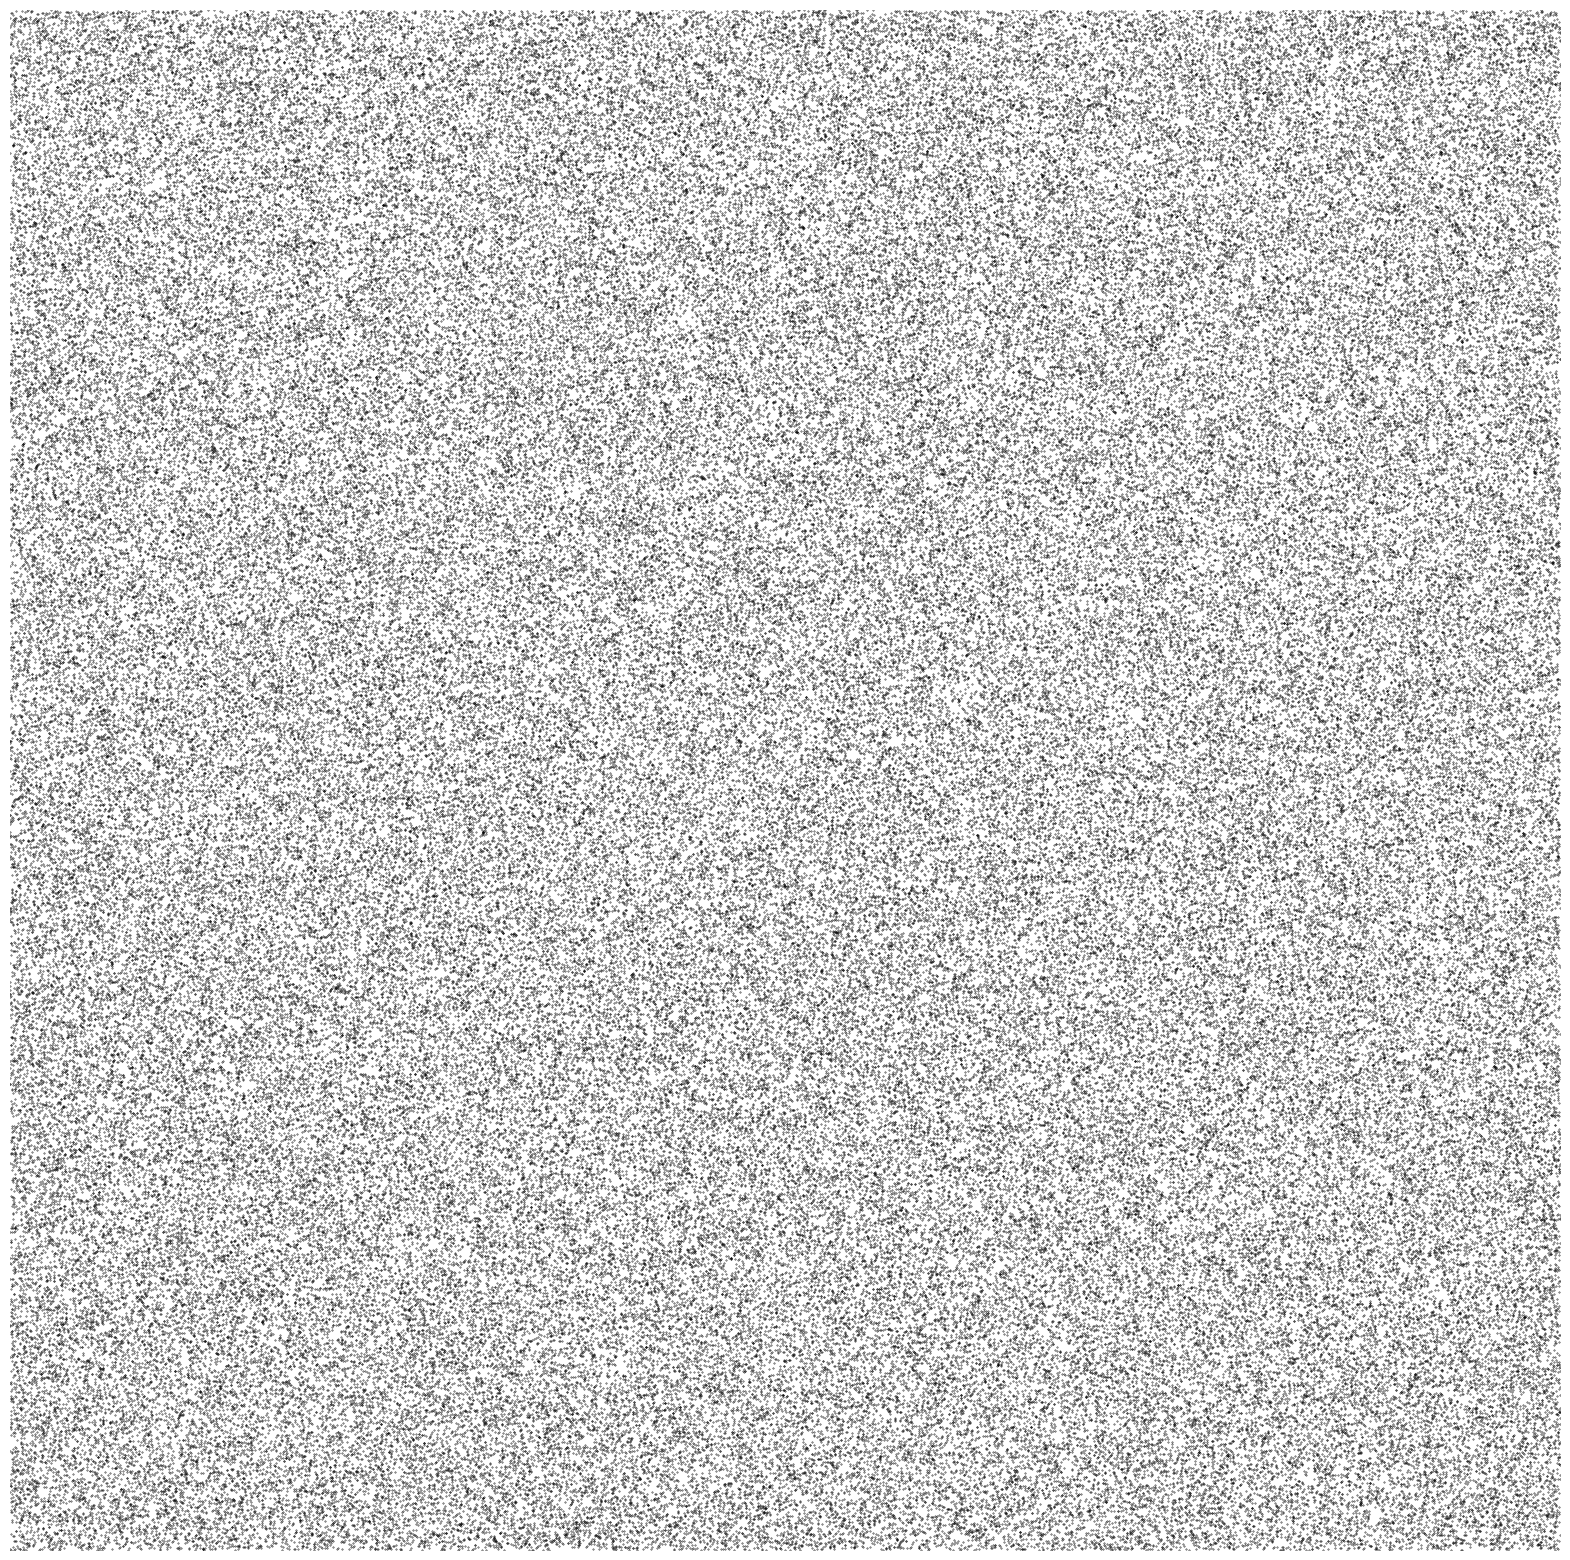

In [4]:
plt.figure(figsize=(20, 20))
plt.scatter(pts[:, 0], pts[:, 1], s=0.1, color="black")
plt.axis('off')  
plt.margins(0)   
plt.show()

In [5]:
#just some packing here
points = sqnet.map(pts).reshape(-1, D)

In [6]:
def energy(norm2, sigma2 = (3/I)**2):
    e = jnp.exp(-norm2/sigma2)
    return jnp.mean(e)

In [7]:
wr = 5

ground_pts = ground_state(points, IJ=IJ, wr=wr, energy_fun = energy, max_iter = 10, lr = 3)

In [8]:
lr_list = np.exp(np.linspace(np.log(0.3), np.log(3), 3))[::-1]
print(lr_list)

[3.        0.9486833 0.3      ]


In [9]:
for i, lr in enumerate(lr_list):
    print(i)
    sqnet = SquareNet(IJ_ = IJ)
    sqnet.fit(ground_pts)

    ground_pts = sqnet.map(ground_pts).reshape(-1, D)
    ground_pts = ground_state(ground_pts, IJ=IJ, wr=wr, energy_fun = energy, max_iter = 10, lr = lr)

0
succesfully sorted at iteration 10
1
succesfully sorted at iteration 8
2
succesfully sorted at iteration 8


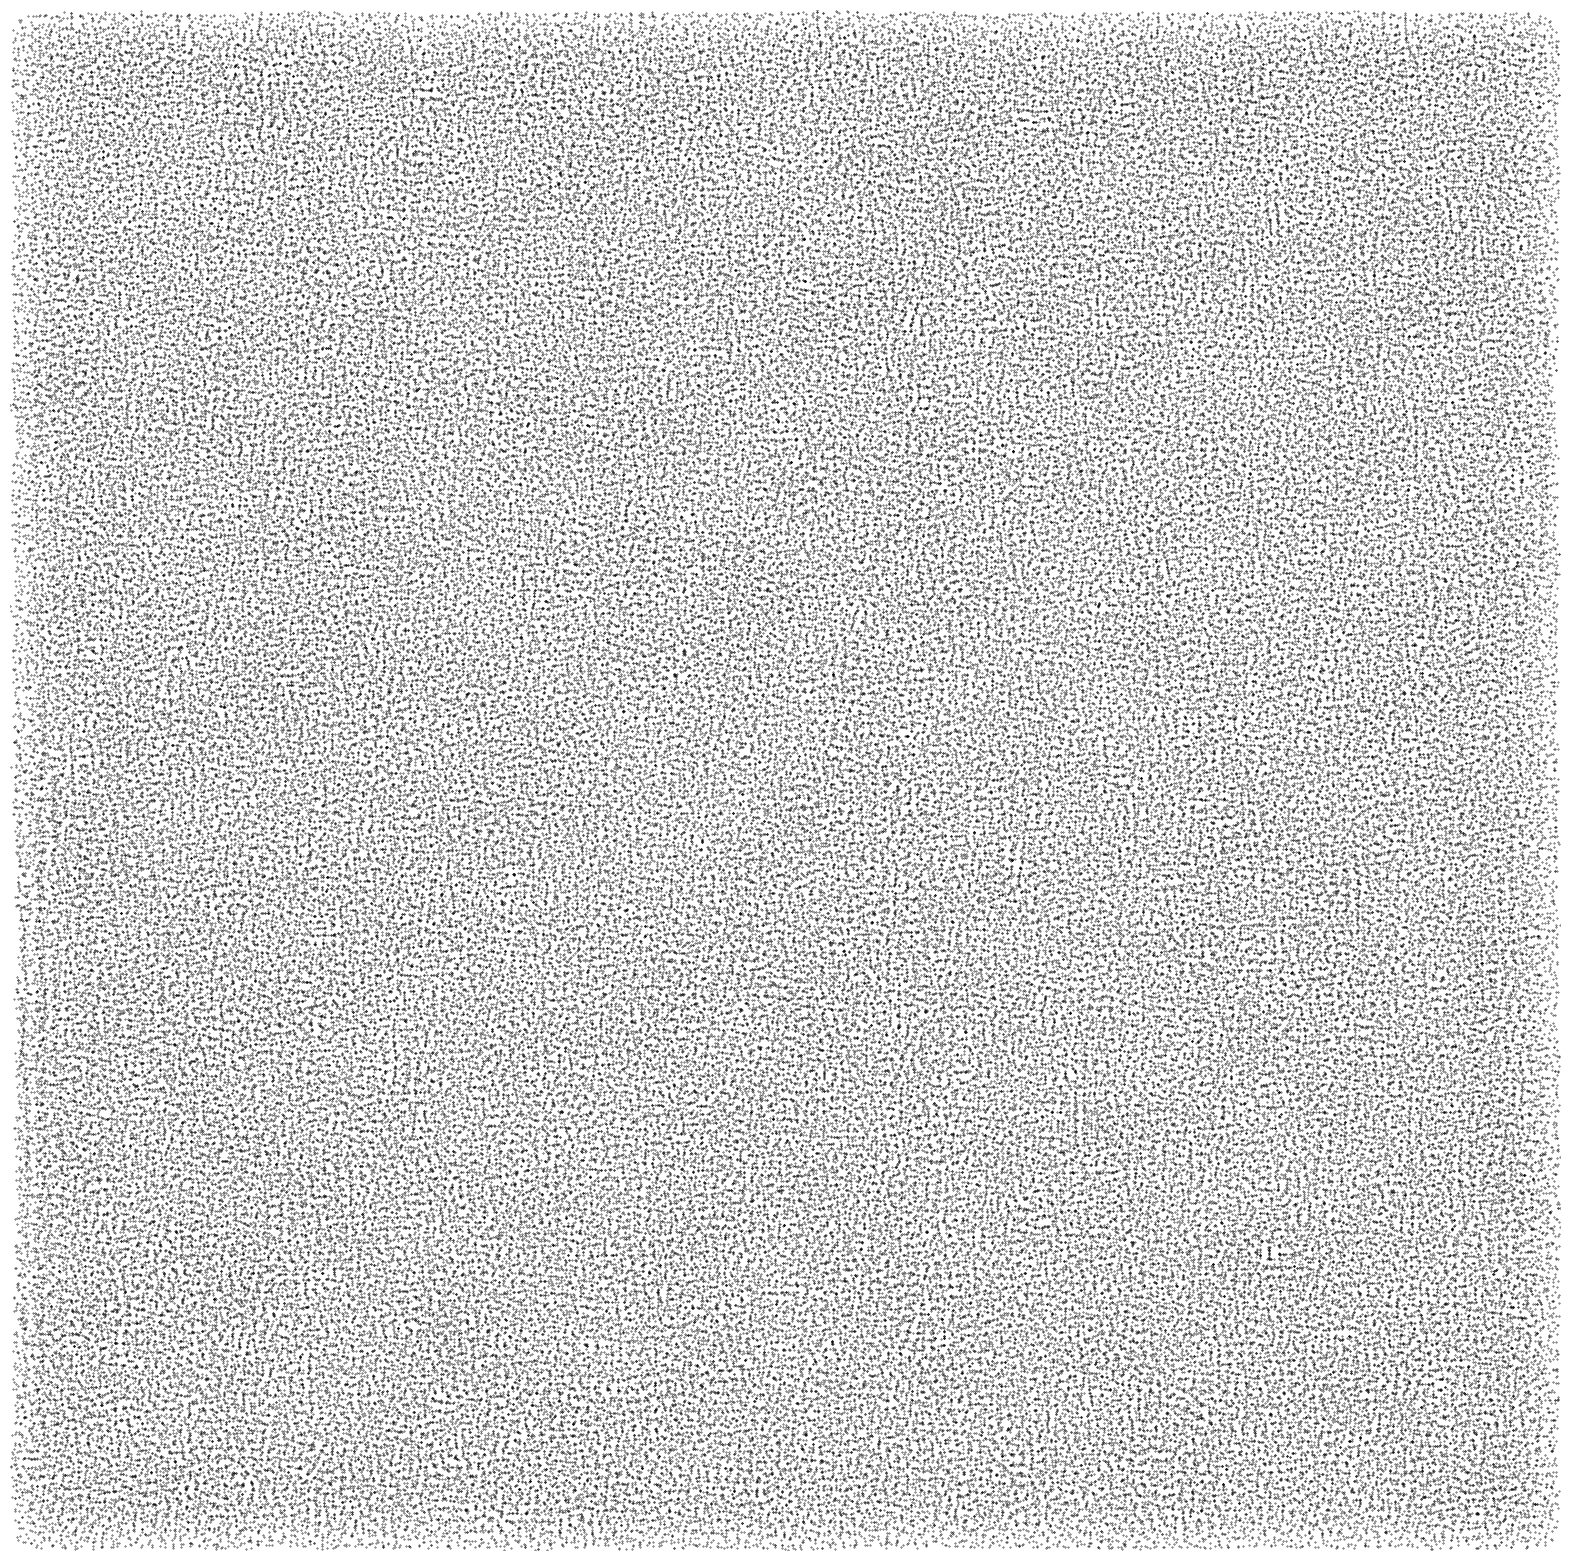

In [10]:
plt.figure(figsize=(20, 20))
plt.scatter(ground_pts[:, 0], ground_pts[:, 1], s=0.1, color="black")
plt.axis('off')  
plt.margins(0)   
plt.show()